<a href="https://colab.research.google.com/github/specM7/DSGP-Test/blob/main/Test_DSGP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# If running in Colab and torch/torchvision isn't installed yet, uncomment:
!pip -q install torch torchvision

import os
import json
import numpy as np
import random
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

import joblib

# EfficientNet-B0 feature extractor (torchvision)
import torch
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

FEATURE_EXTRACTOR_NAME = "efficientnet_b0"
IMAGE_SIZE = 224


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# Directories for training and testing data
# train_dir = '/content/drive/MyDrive/Training'
train_dir = '/content/drive/MyDrive/new2'

# Define image size for EfficientNet-B0
IMAGE_SIZE = 224


# # Load and shuffle the train data
# train_paths = []
# train_labels = []
# train_paths = []
# train_labels = []

# for label in os.listdir(train_dir):
#     label_path = os.path.join(train_dir, label)

#     # # Skip if this entry is not a directory
#     # if os.path.isdir(label_path)== False:
#     #     continue
#     train_paths.append(label_path)
#     train_labels.append(label_path)
train_paths = []
train_labels = []

for fname in os.listdir(train_dir):
    fname_lower = fname.lower()

    if not fname_lower.endswith(('.jpg', '.jpeg', '.png')):
        continue

    if 'tr-pi_' in fname_lower:
        label = 'pi'
    # elif 'tr-no_' in fname_lower:
    #     label = 'no'
    else:
        label = 'no'  # skip unknown files

    train_paths.append(os.path.join(train_dir, fname))
    train_labels.append(label)
from sklearn.model_selection import train_test_split

X_paths_train, X_paths_test, y_train, y_test = train_test_split(
    train_paths,
    train_labels,
    test_size=0.25,
    stratify=train_labels,   # ensures mix of pi & no
    random_state=42
)

print(f"Loaded {len(train_paths)} images")
print("Class distribution:")
from collections import Counter
print(Counter(train_labels))


Loaded 934 images
Class distribution:
Counter({'pi': 500, 'no': 434})


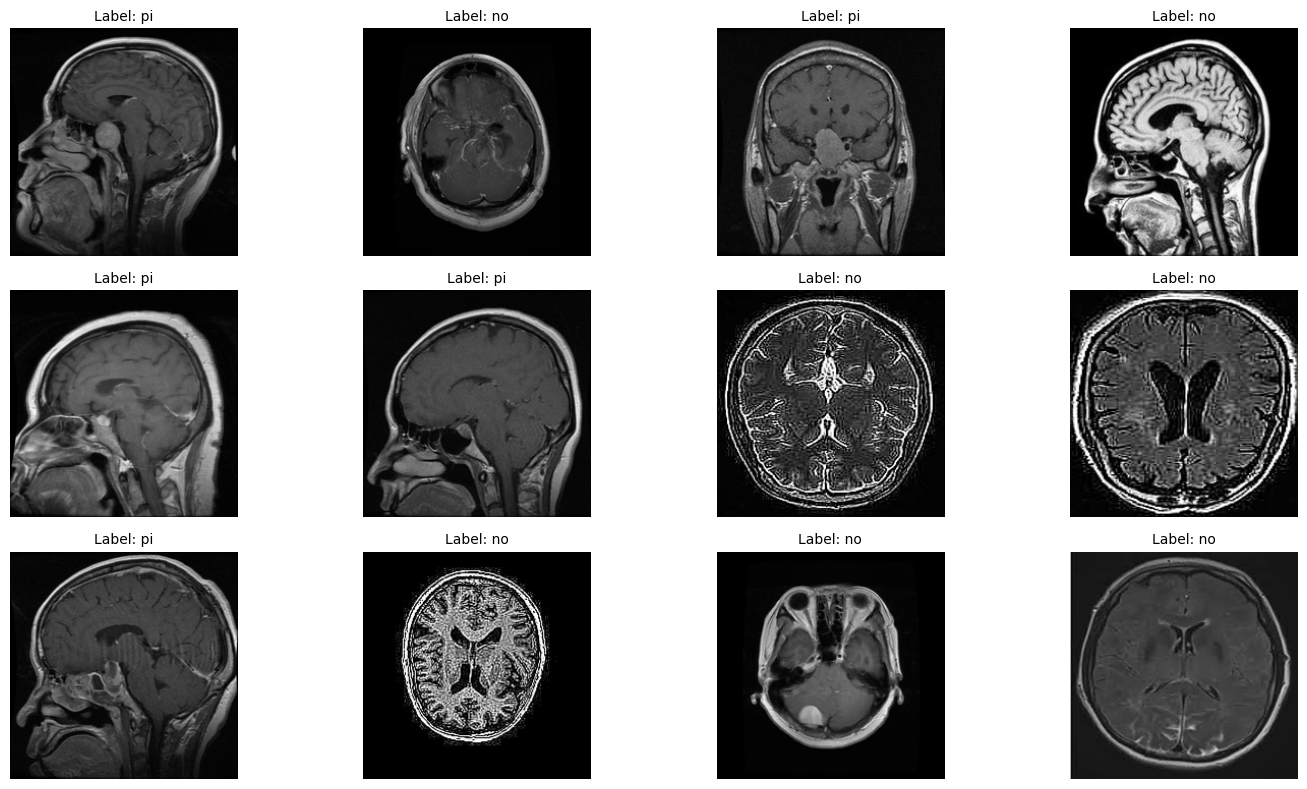

In [20]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
# random_indices = random.sample(range(len(train_paths)), 12)
num_images_to_show = min(12, len(train_paths))
random_indices = random.sample(range(len(train_paths)), num_images_to_show)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(3, 4, figsize=(15, 8))
axes = axes.ravel()

for i_display, idx_original in enumerate(random_indices):
    # Load image using the original index from train_paths
    img_path = train_paths[idx_original]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image on the i_display-th axis
    axes[i_display].imshow(img)
    axes[i_display].axis('off')  # Hide axis
    # Display class label
    axes[i_display].set_title(f"Label: {train_labels[idx_original]}", fontsize=10)

plt.tight_layout()
plt.show()

In [21]:
# Light augmentation on PIL images (optional)
def augment_image_pil(img):
    img = img.convert('RGB')
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
    return img

# Load images as PIL (torchvision weights/transforms will handle normalization)
def open_pil_images(paths, image_size=None, augment=False):
    images = []
    for path in paths:
        img = Image.open(path).convert('RGB')
        if image_size is not None:
            img = img.resize((image_size, image_size))
        if augment:
            img = augment_image_pil(img)
        images.append(img)
    return images

# Encoding labels (convert label names to integers)
def encode_label(labels):
    label_map = {'no': 0, 'pi': 1}
    return np.array([label_map[label] for label in labels])


In [22]:
# Load EfficientNet-B0 model for feature extraction
def create_efficientnet_b0_feature_extractor(device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    weights = EfficientNet_B0_Weights.DEFAULT
    preprocess = weights.transforms()

    model = efficientnet_b0(weights=weights)
    model.classifier = torch.nn.Identity()
    model.eval()
    model.to(device)

    return model, preprocess, device

# Feature extraction using EfficientNet-B0 (global pooled embedding)
def extract_efficientnet_features(paths, labels, feature_extractor, preprocess, device, batch_size=16, augment=False):
    all_features = []
    encoded_labels = encode_label(labels)

    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        batch_images = open_pil_images(batch_paths, augment=augment)

        batch_tensor = torch.stack([preprocess(img) for img in batch_images]).to(device)

        with torch.no_grad():
            feats = feature_extractor(batch_tensor).detach().cpu().numpy()

        all_features.append(feats)

    all_features = np.vstack(all_features)
    print(f"All features shape: {all_features.shape}")
    return all_features, encoded_labels


In [23]:
# Create and train the hybrid model: EfficientNet-B0 feature extractor + (PCA) + Random Forest
def create_hybrid_model(use_pca=True, pca_variance=0.98):
    feature_extractor, preprocess, device = create_efficientnet_b0_feature_extractor()

    X_train_feat, y_train_enc = extract_efficientnet_features(
        X_paths_train, y_train, feature_extractor, preprocess, device, augment=True
    )

    X_test_feat, y_test_enc = extract_efficientnet_features(
        X_paths_test, y_test, feature_extractor, preprocess, device, augment=False
    )

    n_trees_options = [30,80,120,200,400]
    train_acc = []
    test_acc = []

    best_model = None
    best_test_acc = -1
    best_test_pred = None
    best_n_trees = None

    for n_trees in n_trees_options:
        rf = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        )

        if use_pca:
            # If pca_variance is a float in (0, 1], sklearn requires svd_solver='full'
            if isinstance(pca_variance, float) and 0 < pca_variance <= 1:
                pca = PCA(n_components=pca_variance, svd_solver='full')
            else:
                pca = PCA(n_components=pca_variance, svd_solver='randomized', random_state=42)

            model = Pipeline([
                ('pca', pca),
                ('rf', rf)
            ])
        else:
            model = rf

        model.fit(X_train_feat, y_train_enc)

        train_pred = model.predict(X_train_feat)
        test_pred = model.predict(X_test_feat)

        train_acc.append(accuracy_score(y_train_enc, train_pred))
        test_acc.append(accuracy_score(y_test_enc, test_pred))

        if test_acc[-1] > best_test_acc:
            best_test_acc = test_acc[-1]
            best_model = model
            best_test_pred = test_pred
            best_n_trees = n_trees

        print(f"Trees: {n_trees}")
        print(f"  Train acc: {train_acc[-1]:.4f}")
        print(f"  Test acc : {test_acc[-1]:.4f}")

    plt.figure(figsize=(8, 5))
    plt.plot(n_trees_options, train_acc, marker='o', label='Training Accuracy')
    plt.plot(n_trees_options, test_acc, marker='o', label='Testing Accuracy')
    plt.xlabel("Number of Trees")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve: EfficientNet-B0 + PCA + Random Forest" if use_pca else "Learning Curve: EfficientNet-B0 + Random Forest")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\nBest model: {best_n_trees} trees | Test acc: {best_test_acc:.4f}\n")

    label_map = {0: "no", 1: "pi"}
    for i in range(min(15, len(X_paths_test))):
        pred_label = label_map[best_test_pred[i]]
        true_label = y_test[i]
        print(f"Image: {os.path.basename(X_paths_test[i])} | Predicted: {pred_label} | Actual: {true_label}")

    # We don't save EfficientNet weights (pretrained); we recreate the extractor during inference.
    return best_model


In [24]:
# Predict using EfficientNet-B0 features + trained RandomForest/PCA pipeline
def predict_images(paths, feature_extractor, preprocess, device, rf_classifier, batch_size=16):
    all_predictions = []
    all_probabilities = []

    label_map = {0: "no", 1: "pi"}

    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        batch_images = open_pil_images(batch_paths, augment=False)

        batch_tensor = torch.stack([preprocess(img) for img in batch_images]).to(device)

        with torch.no_grad():
            feats = feature_extractor(batch_tensor).detach().cpu().numpy()

        batch_predictions = rf_classifier.predict(feats)
        batch_probabilities = rf_classifier.predict_proba(feats)

        decoded_predictions = [label_map[pred] for pred in batch_predictions]

        all_predictions.extend(decoded_predictions)
        all_probabilities.append(batch_probabilities)

    all_probabilities = np.vstack(all_probabilities)
    return all_predictions, all_probabilities

# Note: ViT attention heatmaps were removed when switching to EfficientNet-B0.


In [25]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def compute_training_accuracy(feature_extractor, preprocess, device, rf_classifier, paths, labels):
    features, encoded_labels = extract_efficientnet_features(paths, labels, feature_extractor, preprocess, device, augment=False)
    predictions = rf_classifier.predict(features)
    accuracy = accuracy_score(encoded_labels, predictions)
    return accuracy


In [26]:
def plot_training_accuracy(accuracy):
    plt.figure(figsize=(6, 4))
    plt.plot([1], [accuracy], marker='o')
    plt.ylim(0, 1)
    plt.xticks([1], ['Training'])
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy of Hybrid EfficientNet-B0 + Random Forest Model')
    plt.grid(True)
    plt.show()


In [27]:
# Save only the sklearn classifier/pipeline and a small config

def save_model(rf_classifier, save_dir, feature_extractor_name=FEATURE_EXTRACTOR_NAME):
    os.makedirs(save_dir, exist_ok=True)

    joblib.dump(rf_classifier, os.path.join(save_dir, "rf_classifier.pkl"))

    cfg = {
        "feature_extractor": feature_extractor_name,
        "image_size": IMAGE_SIZE
    }

    with open(os.path.join(save_dir, "config.json"), "w", encoding="utf-8") as f:
        json.dump(cfg, f)

    print("Model saved successfully.")


In [28]:
# Load the sklearn classifier/pipeline + config

def load_saved_model(save_dir):
    rf_classifier = joblib.load(os.path.join(save_dir, "rf_classifier.pkl"))

    cfg_path = os.path.join(save_dir, "config.json")
    feature_extractor_name = FEATURE_EXTRACTOR_NAME

    if os.path.exists(cfg_path):
        with open(cfg_path, "r", encoding="utf-8") as f:
            cfg = json.load(f)
        feature_extractor_name = cfg.get("feature_extractor", FEATURE_EXTRACTOR_NAME)

    print("Model loaded successfully.")
    return rf_classifier, feature_extractor_name


All features shape: (700, 1280)
All features shape: (234, 1280)
Trees: 30
  Train acc: 1.0000
  Test acc : 0.8932
Trees: 80
  Train acc: 1.0000
  Test acc : 0.9145
Trees: 120
  Train acc: 1.0000
  Test acc : 0.9103
Trees: 200
  Train acc: 1.0000
  Test acc : 0.9188
Trees: 400
  Train acc: 1.0000
  Test acc : 0.9274


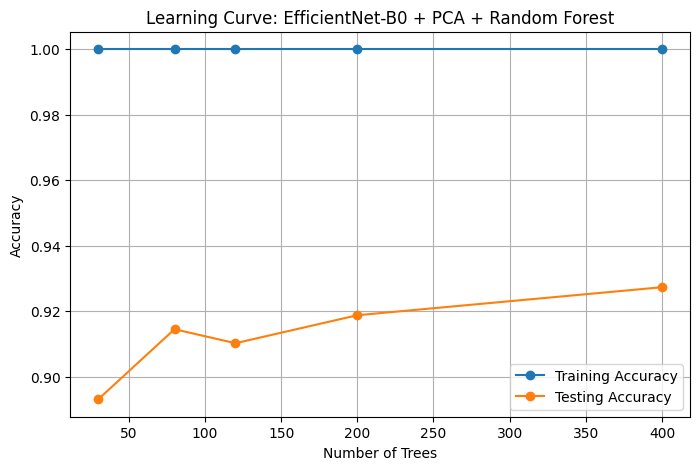


Best model: 400 trees | Test acc: 0.9274

Image: Tr-gl_0071.jpg | Predicted: no | Actual: no
Image: Tr-me_0061.jpg | Predicted: no | Actual: no
Image: Tr-pi_0385.jpg | Predicted: pi | Actual: pi
Image: Tr-me_0824.jpg | Predicted: no | Actual: no
Image: Tr-no_0049.jpg | Predicted: no | Actual: no
Image: Tr-pi_0053.jpg | Predicted: pi | Actual: pi
Image: Tr-me_0123.jpg | Predicted: pi | Actual: no
Image: Tr-pi_0473.jpg | Predicted: pi | Actual: pi
Image: Tr-pi_0191.jpg | Predicted: pi | Actual: pi
Image: Tr-pi_0370.jpg | Predicted: pi | Actual: pi
Image: Tr-pi_0440.jpg | Predicted: pi | Actual: pi
Image: Tr-pi_0423.jpg | Predicted: pi | Actual: pi
Image: Tr-me_0082.jpg | Predicted: no | Actual: no
Image: Tr-no_0122.jpg | Predicted: no | Actual: no
Image: Tr-pi_0350.jpg | Predicted: pi | Actual: pi


In [29]:
# STEP 1: Train the hybrid model (EfficientNet-B0 features + RF/PCA)
rf_classifier = create_hybrid_model(use_pca=True, pca_variance=0.98)


In [30]:
# STEP 2: Save model to Google Drive
MODEL_SAVE_PATH = "/content/drive/MyDrive/hybrid_efficientnetb0_rf_model"

save_model(rf_classifier, MODEL_SAVE_PATH, FEATURE_EXTRACTOR_NAME)

# STEP 3: Load saved model
rf_classifier_loaded, feature_extractor_name_loaded = load_saved_model(MODEL_SAVE_PATH)


Model saved successfully.
Model loaded successfully.


Saving Tr-gl_0064.jpg to Tr-gl_0064.jpg
Uploaded image: Tr-gl_0064.jpg


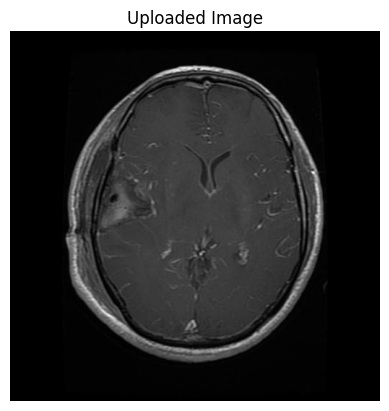

Model loaded successfully.

==================== PREDICTION ====================
 PREDICTION: NO PITUITARY TUMOR DETECTED
Confidence (Tumor Probability): 0.2950


In [31]:
# UPLOAD IMAGE AND PREDICT (EfficientNet-B0 features)

from google.colab import files
import os
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

print(f"Uploaded image: {image_path}")

img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

rf_classifier, feature_extractor_name = load_saved_model(MODEL_SAVE_PATH)
feature_extractor, preprocess, device = create_efficientnet_b0_feature_extractor()

predictions, probabilities = predict_images(
    paths=[image_path],
    feature_extractor=feature_extractor,
    preprocess=preprocess,
    device=device,
    rf_classifier=rf_classifier
)

predicted_label = predictions[0]
tumor_probability = probabilities[0][1]

print("\n==================== PREDICTION ====================")
if predicted_label == 'pi':
    print(" PREDICTION: PITUITARY TUMOR DETECTED")
else:
    print(" PREDICTION: NO PITUITARY TUMOR DETECTED")
print(f"Confidence (Tumor Probability): {tumor_probability:.4f}")
print("====================================================")

# (No attention heatmap for EfficientNet-B0)


In [32]:
# plt.figure(figsize=(8,4))
# plt.grid(True)
# plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
# plt.plot(history.history['loss'], '.r-', linewidth=2)
# plt.title('Model Training History')
# plt.xlabel('epoch')
# plt.xticks([x for x in range(epochs)])
# plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
# plt.show()